In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/telco_clean.csv")

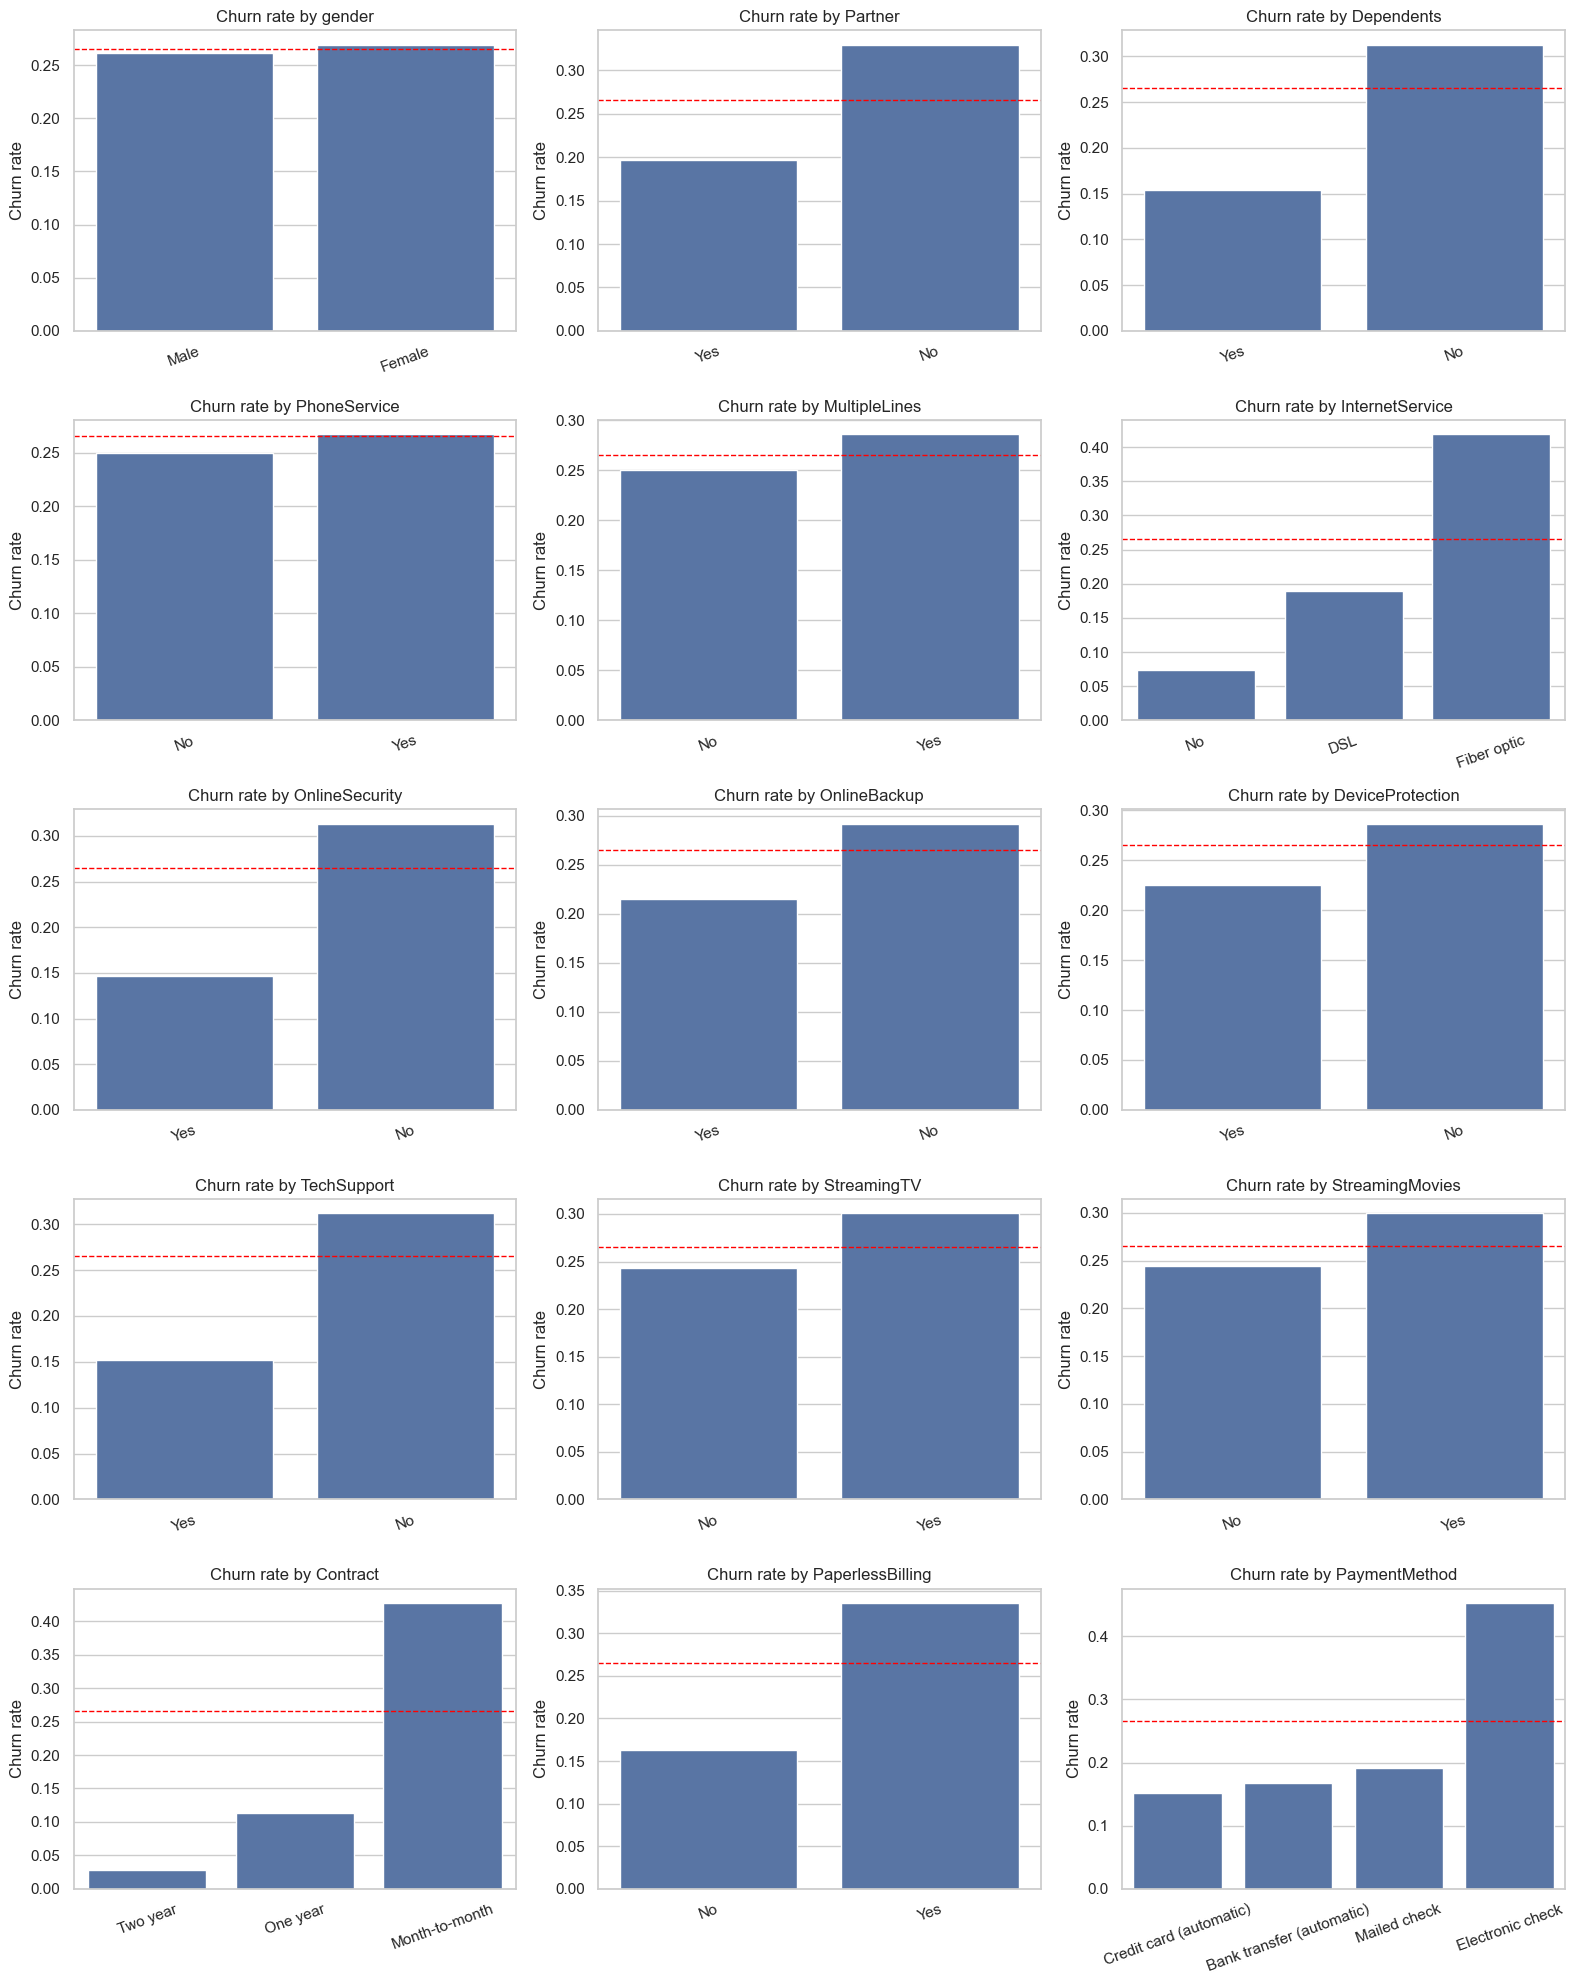

In [2]:
# Churn rate by every categorical feature (red line = overall churn rate)
cat_cols = df.select_dtypes("object").columns.tolist()
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["Churn"].mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.axhline(df["Churn"].mean(), color="red", ls="--", lw=1)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("../reports/churn_rate_by_category.png", dpi=150)
plt.show()

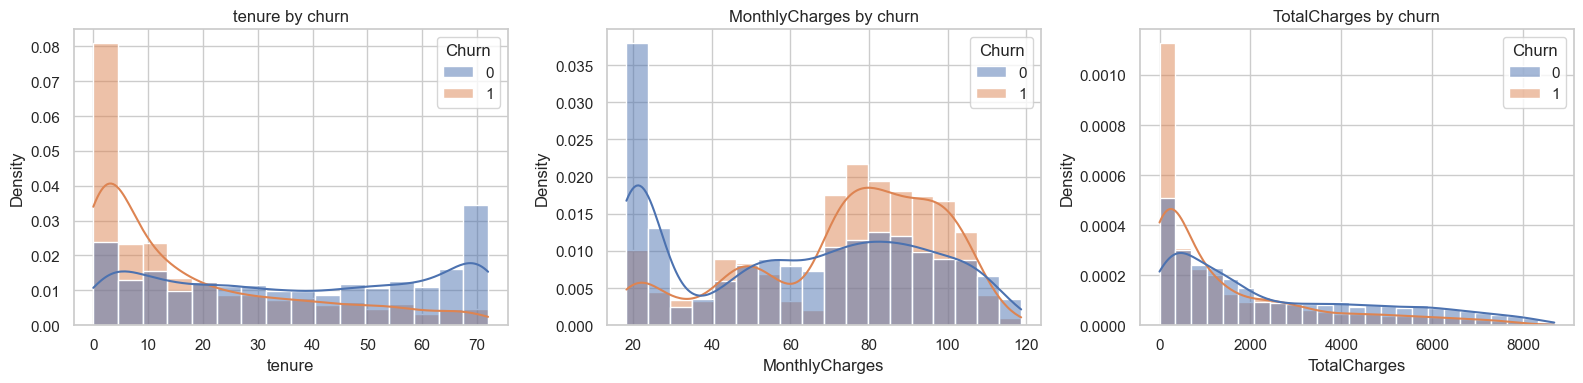

In [3]:
# Numeric features: distribution for churners vs non-churners
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.savefig("../reports/numeric_distributions.png", dpi=150)
plt.show()

In [4]:
# Tenure bands and senior citizens (EDA only, not saved to the dataset)
bands = pd.cut(df["tenure"], [-1, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49-72"])
print(df.groupby(bands, observed=True)["Churn"].agg(["mean", "count"]).round(3))
print()
print(df.groupby("SeniorCitizen")["Churn"].agg(["mean", "count"]).round(3))

         mean  count
tenure              
0-12    0.474   2186
13-24   0.287   1024
25-48   0.204   1594
49-72   0.095   2239

                mean  count
SeniorCitizen              
0              0.236   5901
1              0.417   1142


In [5]:
# Combined segment: contract x internet service
print(df.pivot_table(index="Contract", columns="InternetService",
                     values="Churn", aggfunc="mean").round(3))

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   0.322        0.546  0.189
One year         0.093        0.193  0.025
Two year         0.019        0.072  0.008


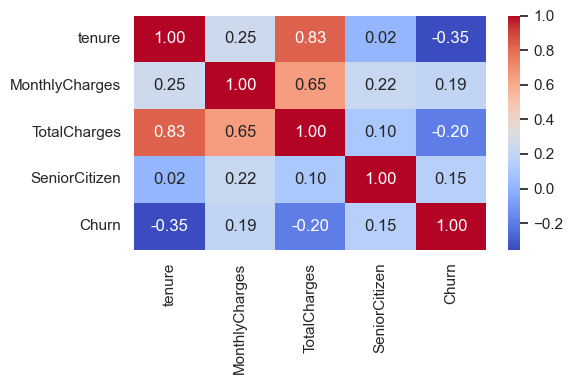

In [6]:
# Correlation of numeric features with churn
plt.figure(figsize=(6, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png", dpi=150)
plt.show()